# Business Entity Resolution: NLP Data Cleaning & EDA

**Task recap** (see `student_resource/README.md`): three sources of noisy business records
(`entity_id`, `business_name`, `business_address`, `country`). Source 1 is the deduplicated
reference; for each S1 entity we must find all S2/S3 records describing the same business.
Scored with a per-entity macro **F0.5** (precision-heavy, singletons count).

This notebook covers the standard NLP groundwork before any modelling:

1. **Setup & loading**: memory-aware, sample-based loading (the raw TSVs are ~2.5 GB)
2. **Structural EDA**: sizes, schema, IDs, missing values, country mix
3. **Ground-truth EDA**: cluster sizes, singletons, S2/S3 composition
4. **Raw-text EDA**: lengths, casing, scripts, and a catalogue of noise patterns
5. **Cleaning pipeline**: encoding repair, transliteration, name & address normalisation
6. **Post-cleaning EDA**: vocabulary, legal forms, n-grams, source overlap
7. **Pair-level EDA**: how much cleaning separates matches from non-matches; blocking keys
8. **Train vs test drift**: the unseen `France` country
9. **Full-data cleaning export** (chunked, to parquet)

Everything here uses only the provided data plus offline open-source libraries; no external lookups.

In [1]:
# Dependencies (all offline, permissively licensed):
# %pip install pandas pyarrow numpy matplotlib ftfy anyascii rapidfuzz

import csv
import re
import time
import unicodedata
from collections import Counter
from itertools import islice
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from anyascii import anyascii
from ftfy import fix_text
from rapidfuzz import fuzz

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

SEED = 42
rng = np.random.default_rng(SEED)

# Memory knobs: the raw files hold millions of rows; EDA runs on samples.
SAMPLE_ROWS = 300_000       # random rows kept per source file for univariate EDA
N_GT_ENTITIES = 20_000      # S1 entities sampled from the ground truth for pair-level EDA
CHUNK = 500_000             # rows per chunk when streaming a file
RUN_FULL_CLEAN = False      # set True to clean every file end-to-end and write parquet (section 9)


def find_dataset_dir(start: Path = Path.cwd()) -> Path:
    for base in [start, *start.parents]:
        hits = sorted(base.glob("**/student_resource/dataset"))
        hits = [h for h in hits if "__MACOSX" not in h.parts]
        if hits:
            return hits[0]
    raise FileNotFoundError("student_resource/dataset not found; set DATA_DIR manually")


DATA_DIR = find_dataset_dir()
OUT_DIR = DATA_DIR.parent.parent.parent / "cleaned"
FILES = {
    ("train", "S1"): DATA_DIR / "train/train_source1.tsv",
    ("train", "S2"): DATA_DIR / "train/train_source2.tsv",
    ("train", "S3"): DATA_DIR / "train/train_source3.tsv",
    ("test", "S1"): DATA_DIR / "test/test_source1.tsv",
    ("test", "S2"): DATA_DIR / "test/test_source2.tsv",
    ("test", "S3"): DATA_DIR / "test/test_source3.tsv",
}
GT_FILE = DATA_DIR / "train/train_ground_truth.tsv"
print(DATA_DIR)

c:\Users\Mitaksh Jhanwar\Downloads\Epoch-Alypse\6ab10eb3b23ba_student_resource\student_resource\dataset


In [2]:
# Plot styling: fixed categorical colours (colour follows the entity, never its rank).
SOURCE_COLORS = {"S1": "#2a78d6", "S2": "#eb6834", "S3": "#1baf7a"}
COUNTRY_COLORS = {"US": "#2a78d6", "India": "#eb6834", "France": "#1baf7a"}
MATCH_COLORS = {"match": "#2a78d6", "non-match (random)": "#eb6834", "non-match (hard)": "#1baf7a"}
MUTED = "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": "#0b0b0b",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e4e3df",
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "legend.frameon": False,
    "font.size": 10,
})


def barh(ax, series, color, title, fmt="{:,.0f}"):
    """Horizontal bar chart with selective value labels, largest at top."""
    s = series.iloc[::-1]
    ax.barh(s.index.astype(str), s.values, color=color, height=0.7)
    for y, v in enumerate(s.values):
        ax.text(v, y, " " + fmt.format(v), va="center", fontsize=8, color=MUTED)
    ax.set_title(title, loc="left", fontsize=11)
    ax.grid(axis="y", visible=False)

## 1. Loading

Notes from inspecting the raw bytes:
* Files are **tab-separated** (addresses and ID lists contain commas). No quoting is used, so we
  read with `quoting=QUOTE_NONE` and treat a stray `"` as ordinary text.
* Missing values appear as empty cells **and** as literal `null` (sometimes as an address
  component: `414 SHERWOOD DRIVE, null, RUSSELLVILLE, AR`). We read everything as strings with
  `keep_default_na=False` and handle missingness explicitly, so the string `"NA"` or a company
  literally called `None` is not silently dropped.
* Files are too large to load whole on a small machine, so we stream them in chunks and keep a
  uniform random sample, plus any IDs we explicitly need (ground-truth pairs).

In [3]:
READ_KW = dict(sep="\t", dtype=str, quoting=csv.QUOTE_NONE, keep_default_na=False, encoding="utf-8")


def count_rows(path: Path) -> int:
    n = 0
    with open(path, "rb") as f:
        while buf := f.read(1 << 24):
            n += buf.count(b"\n")
    return n - 1  # header


def scan(path: Path, frac: float = 0.0, keep_ids: set | None = None, seed: int = SEED) -> pd.DataFrame:
    """Stream a TSV and keep a random `frac` of rows plus any rows whose first column is in `keep_ids`."""
    r = np.random.default_rng(seed)
    parts = []
    for chunk in pd.read_csv(path, chunksize=CHUNK, **READ_KW):
        mask = r.random(len(chunk)) < frac
        if keep_ids:
            mask |= chunk.iloc[:, 0].isin(keep_ids).to_numpy()
        parts.append(chunk[mask])
    return pd.concat(parts, ignore_index=True)


t0 = time.time()
sizes = pd.DataFrame(
    [(split, src, p.stat().st_size / 1e6, count_rows(p)) for (split, src), p in FILES.items()]
    + [("train", "GT", GT_FILE.stat().st_size / 1e6, count_rows(GT_FILE))],
    columns=["split", "file", "MB", "rows"],
)
print(f"counted in {time.time() - t0:.0f}s")
sizes.style.format({"MB": "{:,.0f}", "rows": "{:,}"})

counted in 7s


,split,file,MB,rows
0,train,S1,210,"2,206,821"
1,train,S2,489,"5,034,616"
2,train,S3,504,"5,285,603"
3,test,S1,175,"1,732,544"
4,test,S2,509,"4,887,273"
5,test,S3,506,"5,082,316"
6,train,GT,127,"2,206,821"


## 2. Ground truth: load fully (two columns, compact) and sample entities for pair analysis

In [4]:
gt = pd.read_csv(GT_FILE, **READ_KW)
gt["matched_entity_ids"] = gt["matched_entity_ids"].str.strip()
gt["n_match"] = np.where(gt.matched_entity_ids == "", 0, gt.matched_entity_ids.str.count(",") + 1)
gt["n_s2"] = gt.matched_entity_ids.str.count(r"\bS2-")
gt["n_s3"] = gt.matched_entity_ids.str.count(r"\bS3-")
gt["country"] = None  # filled from S1 below

# Entities used for the pair-level EDA (section 7): sampled up front so one pass over each source
# file collects both the random sample and the specific records these entities need.
gt_sample = gt.sample(N_GT_ENTITIES, random_state=SEED)
pairs_gt = (
    gt_sample.assign(match_id=gt_sample.matched_entity_ids.str.split(","))
    .explode("match_id")
    .query("match_id != ''")[["source1_entity_id", "match_id"]]
)
need_ids = set(gt_sample.source1_entity_id) | set(pairs_gt.match_id)
print(f"{len(gt):,} GT rows; sampled {len(gt_sample):,} entities → {len(pairs_gt):,} true pairs")

2,206,821 GT rows; sampled 20,000 entities → 69,493 true pairs


In [5]:
t0 = time.time()
raw = {}
for (split, src), path in FILES.items():
    n = sizes.query("split == @split and file == @src").rows.item()
    df = scan(path, frac=SAMPLE_ROWS / n, keep_ids=need_ids if split == "train" else None)
    df["source"], df["split"] = src, split
    raw[(split, src)] = df
    print(f"{split}/{src}: kept {len(df):,} rows  ({time.time() - t0:.0f}s)")

# `sample` = the uniform random part only (the GT-needed rows would bias univariate stats)
data = pd.concat(raw.values(), ignore_index=True)
s1_n = dict(zip(sizes.file + sizes.split, sizes.rows))
data["in_sample"] = True
train_needed = data.split.eq("train") & data.entity_id.isin(need_ids)
# A needed row may also have been drawn randomly; re-draw membership so the sample stays uniform.
data.loc[train_needed, "in_sample"] = rng.random(train_needed.sum()) < [
    SAMPLE_ROWS / s1_n[s + "train"] for s in data.loc[train_needed, "source"]
]
sample = data[data.in_sample].reset_index(drop=True)
data.memory_usage(deep=True).sum() / 1e6

train/S1: kept 317,050 rows  (8s)
train/S2: kept 331,551 rows  (27s)
train/S3: kept 333,621 rows  (47s)
test/S1: kept 299,804 rows  (53s)
test/S2: kept 299,979 rows  (71s)
test/S3: kept 299,960 rows  (90s)


np.float64(755.444234)

## 3. Structural EDA

In [6]:
print("columns:", {k: list(v.columns[:4]) for k, v in islice(raw.items(), 1)})

checks = []
for (split, src), df in raw.items():
    ids = df.entity_id
    checks.append({
        "split": split, "source": src, "rows_kept": len(df),
        "bad_prefix": (~ids.str.startswith(src + "-")).sum(),
        "dup_ids": ids.duplicated().sum(),
        "dup_name+addr": df.duplicated(["business_name", "business_address", "country"]).sum(),
        "name_empty": df.business_name.str.strip().isin(["", "null", "NULL"]).sum(),
        "addr_empty": df.business_address.str.strip().isin(["", "null", "NULL"]).sum(),
        "addr_has_null_component": df.business_address.str.contains(r"(?:^|,)\s*null\s*(?:,|$)", case=False).sum(),
        "country_empty": df.country.str.strip().eq("").sum(),
    })
checks = pd.DataFrame(checks)
checks

columns: {('train', 'S1'): ['entity_id', 'business_name', 'business_address', 'country']}


,split,source,rows_kept,bad_prefix,dup_ids,dup_name+addr,name_empty,addr_empty,addr_has_null_component,country_empty
0,train,S1,317050,0,0,0,0,0,2,0
1,train,S2,331551,0,0,342,0,11433,5762,0
2,train,S3,333621,0,0,232,0,11473,5530,0
3,test,S1,299804,0,0,0,0,0,2,0
4,test,S2,299979,0,0,100,0,7973,4400,0
5,test,S3,299960,0,0,59,0,7961,4167,0


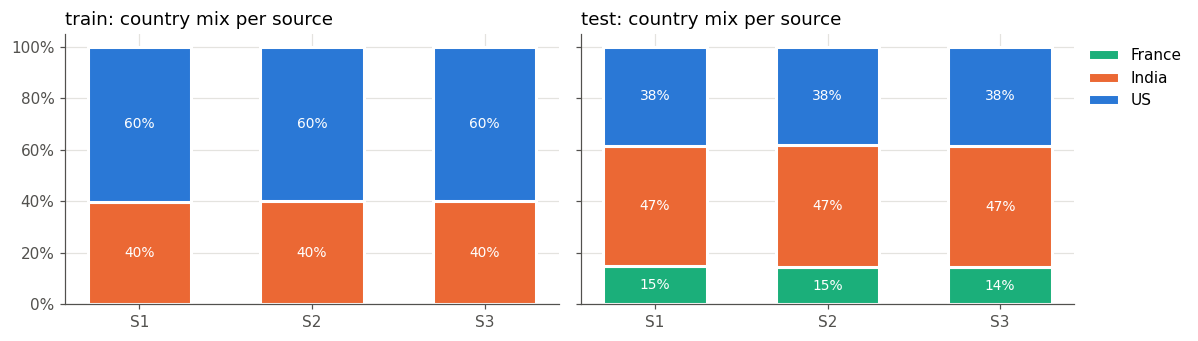

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, split in zip(axes, ["train", "test"]):
    ct = pd.crosstab(sample.query("split == @split").source, sample.query("split == @split").country, normalize="index")
    bottom = np.zeros(len(ct))
    for c in ct.columns:
        ax.bar(ct.index, ct[c], bottom=bottom, color=COUNTRY_COLORS.get(c, MUTED), label=c, width=0.6,
               edgecolor="white", linewidth=2)
        for i, (b, v) in enumerate(zip(bottom, ct[c])):
            if v > 0.06:
                ax.text(i, b + v / 2, f"{v:.0%}", ha="center", va="center", color="white", fontsize=9)
        bottom += ct[c].to_numpy()
    ax.set_title(f"{split}: country mix per source", loc="left")
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

## 4. Ground-truth EDA

In [8]:
s1_country = data.query("split == 'train' and source == 'S1'").set_index("entity_id").country
gt_sample = gt_sample.assign(country=gt_sample.source1_entity_id.map(s1_country))

summary = pd.Series({
    "S1 entities in GT": len(gt),
    "S1 rows in train_source1": s1_n["S1train"],
    "singletons (no match)": (gt.n_match == 0).mean(),
    "mean matches / entity": gt.n_match.mean(),
    "max matches / entity": gt.n_match.max(),
    "entities with S2 match": (gt.n_s2 > 0).mean(),
    "entities with S3 match": (gt.n_s3 > 0).mean(),
})
display(summary.to_frame("value"))

all_matched = gt.matched_entity_ids.str.split(",").explode()
all_matched = all_matched[all_matched != ""]
multi = all_matched.value_counts()
print(f"matched S2/S3 IDs: {len(all_matched):,}; appearing under >1 S1 entity: {(multi > 1).sum():,}")
for src in ["S2", "S3"]:
    n_matched = all_matched.str.startswith(src).sum()
    print(f"{src}: {n_matched:,} of {s1_n[src + 'train']:,} records are matched "
          f"({n_matched / s1_n[src + 'train']:.1%}); the rest are distractors")
del all_matched, multi

,value
S1 entities in GT,2.206821e+06
S1 rows in train_source1,2.206821e+06
singletons (no match),5.584821e-02
mean matches / entity,3.461253e+00
max matches / entity,1.100000e+01
entities with S2 match,8.696111e-01
entities with S3 match,8.793396e-01


matched S2/S3 IDs: 7,638,365; appearing under >1 S1 entity: 0
S2: 3,693,619 of 5,034,616 records are matched (73.4%); the rest are distractors
S3: 3,944,746 of 5,285,603 records are matched (74.6%); the rest are distractors


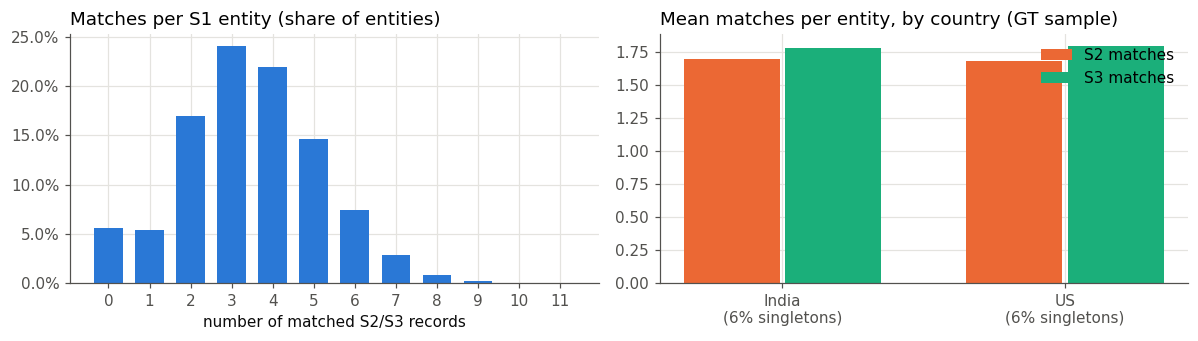

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
vc = gt.n_match.clip(upper=12).value_counts().sort_index()
axes[0].bar(vc.index, vc.values / len(gt), color=SOURCE_COLORS["S1"], width=0.7)
axes[0].set_xticks(vc.index, [str(i) if i < 12 else "12+" for i in vc.index])
axes[0].set_title("Matches per S1 entity (share of entities)", loc="left")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[0].set_xlabel("number of matched S2/S3 records")

by_c = gt_sample.groupby("country").agg(
    singleton=("n_match", lambda s: (s == 0).mean()), s2=("n_s2", "mean"), s3=("n_s3", "mean"))
x = np.arange(len(by_c))
axes[1].bar(x - 0.18, by_c.s2, 0.34, color=SOURCE_COLORS["S2"], label="S2 matches")
axes[1].bar(x + 0.18, by_c.s3, 0.34, color=SOURCE_COLORS["S3"], label="S3 matches")
axes[1].set_xticks(x, [f"{c}\n({s:.0%} singletons)" for c, s in zip(by_c.index, by_c.singleton)])
axes[1].set_title("Mean matches per entity, by country (GT sample)", loc="left")
axes[1].legend()
plt.tight_layout()

## 5. Raw-text EDA

### 5.1 Length and token counts

name_chars  name_tokens  addr_chars  addr_tokens
source country                                                  
S1     India          27.0          4.0        76.0         11.0
       US             22.0          3.0        34.0          6.0
S2     India          27.0          4.0        68.0         10.0
       US             23.0          3.0        32.0          5.0
S3     India          27.0          4.0        58.0          9.0
       US             23.0          3.0        39.0          6.0

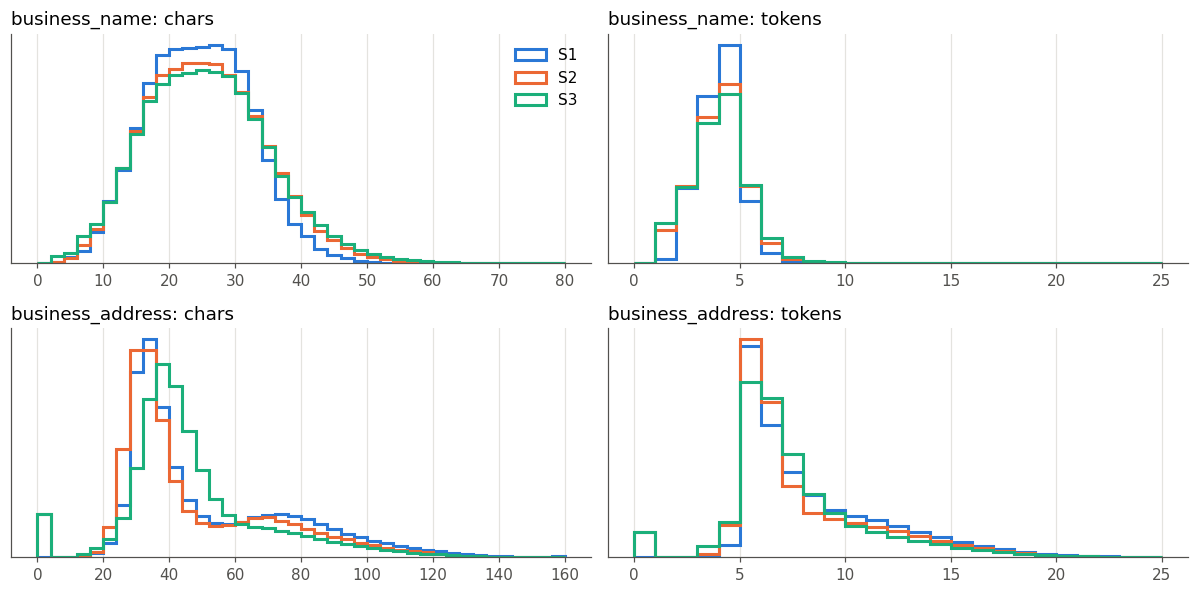

In [10]:
def text_stats(s: pd.Series) -> pd.DataFrame:
    return pd.DataFrame({"chars": s.str.len(), "tokens": s.str.split().str.len()})


fig, axes = plt.subplots(2, 2, figsize=(11, 5.5))
tr = sample.query("split == 'train'")
for row, col in enumerate(["business_name", "business_address"]):
    for j, metric in enumerate(["chars", "tokens"]):
        ax = axes[row, j]
        for src, g in tr.groupby("source"):
            v = text_stats(g[col])[metric]
            hi = 80 if metric == "chars" and col == "business_name" else (160 if metric == "chars" else 25)
            ax.hist(v.clip(upper=hi), bins=40 if metric == "chars" else hi, range=(0, hi), histtype="step",
                    linewidth=2, density=True, color=SOURCE_COLORS[src], label=src)
        ax.set_title(f"{col}: {metric}", loc="left")
        ax.set_yticks([])
axes[0, 0].legend()
plt.tight_layout()

tr.assign(**{f"name_{k}": v for k, v in text_stats(tr.business_name).items()},
          **{f"addr_{k}": v for k, v in text_stats(tr.business_address).items()}) \
  .groupby(["source", "country"])[["name_chars", "name_tokens", "addr_chars", "addr_tokens"]].median()

### 5.2 Casing and writing systems
Source 2 in particular upper-cases many addresses, and a sizeable share of Indian names/addresses
are written in **native Indic scripts** instead of Latin.

In [11]:
def case_style(s: pd.Series) -> pd.Series:
    letters = s.str.replace(r"[^A-Za-z]", "", regex=True)
    return np.select(
        [letters.eq(""), letters.str.isupper(), letters.str.islower(), s.str.istitle()],
        ["no latin letters", "UPPER", "lower", "Title"], "Mixed")


def script_of(text: str) -> str:
    """Dominant non-Latin Unicode script of a string (by character count), or LATIN."""
    c = Counter(unicodedata.name(ch, "UNKNOWN").split()[0] for ch in text if ord(ch) > 0x24F and ch.isalpha())
    return c.most_common(1)[0][0] if c else "LATIN"


for col in ["business_name", "business_address"]:
    cs = pd.crosstab([tr.source], case_style(tr[col]), normalize="index").round(3)
    print(col, "casing"); display(cs)

tr_scripts = pd.DataFrame({
    "source": tr.source, "country": tr.country,
    "name_script": tr.business_name.map(script_of), "addr_script": tr.business_address.map(script_of),
})
display(pd.crosstab([tr_scripts.source, tr_scripts.country], tr_scripts.name_script, normalize="index").round(3))

business_name casing


col_0,Mixed,Title,UPPER,lower,no latin letters
source,,,,,
S1,0.304,0.696,0.00,0.000,0.000
S2,0.195,0.468,0.19,0.057,0.090
S3,0.252,0.608,0.03,0.062,0.047


business_address casing


col_0,Mixed,Title,UPPER,no latin letters
source,,,,
S1,0.600,0.400,0.000,0.000
S2,0.332,0.000,0.635,0.033
S3,0.444,0.523,0.000,0.033


name_script     BENGALI  DEVANAGARI  GUJARATI  GURMUKHI  KANNADA  LATIN  MALAYALAM  ORIYA  TAMIL  TELUGU
source country                                                                                          
S1     India      0.000       0.000     0.000     0.000    0.000  1.000      0.000  0.000  0.000   0.000
       US         0.000       0.000     0.000     0.000    0.000  1.000      0.000  0.000  0.000   0.000
S2     India      0.015       0.131     0.015     0.003    0.018  0.767      0.009  0.004  0.017   0.020
       US         0.000       0.000     0.000     0.000    0.000  1.000      0.000  0.000  0.000   0.000
S3     India      0.008       0.075     0.009     0.002    0.011  0.867      0.005  0.002  0.010   0.011
       US         0.000       0.000     0.000     0.000    0.000  1.000      0.000  0.000  0.000   0.000

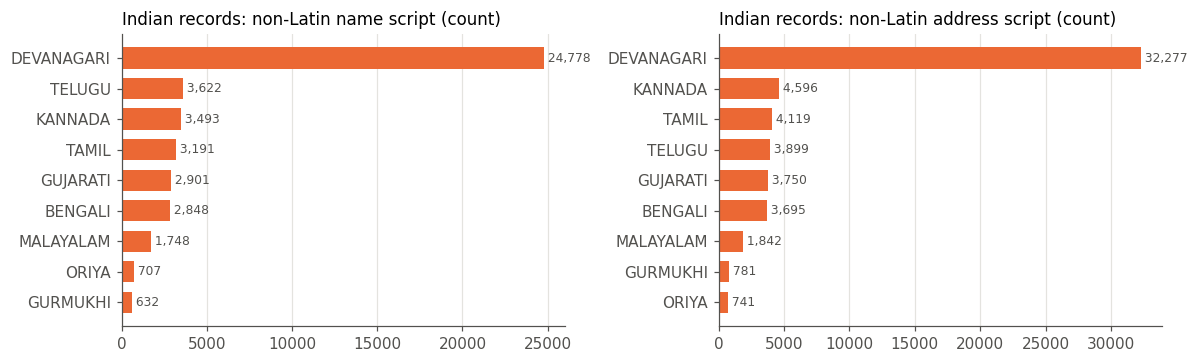

In [12]:
india_nonlatin = tr_scripts.query("country == 'India'")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, title in zip(axes, ["name_script", "addr_script"], ["name", "address"]):
    vc = india_nonlatin.loc[india_nonlatin[col] != "LATIN", col].value_counts()
    barh(ax, vc, SOURCE_COLORS["S2"], f"Indian records: non-Latin {title} script (count)")
plt.tight_layout()

### 5.3 Noise-pattern catalogue
Regex flags for the noise described in the README plus what shows up in the raw rows.
Rates are per source; S1 (the reference) is the cleanest, so the S1 column is a baseline.

In [13]:
NOISE_PATTERNS = {
    # business_name
    "name: leading junk symbols (--, ***, >>, #, @ …)": ("business_name", r"^\s*(?:--|\*{2,}|\.{3}|>>|<<|#|@|\[)"),
    "name: trailing bracket/punct": ("business_name", r"[\)\]!,]\s*$"),
    "name: phone number": ("business_name", r"(?:\+?\d[\d\s-]{8,}\d)"),
    "name: domain / URL": ("business_name", r"(?:www\.|\.(?:com|net|org|in|co|fr|io|biz)\b)"),
    "name: legal form at start": ("business_name", r"(?i)^\W*(?:llc|inc|corp|ltd|pvt|private|limited|sarl|sas)\b"),
    "name: parenthesised part": ("business_name", r"\(.*?\)"),
    "name: '(India)'-style country tag": ("business_name", r"(?i)\((?:india|usa?|france)\)"),
    "name: '&' ampersand": ("business_name", r"&"),
    "name: accented Latin letter": ("business_name", r"[À-ÖØ-öø-ÿ]"),
    "name: mojibake (Ã, Â, â€)": ("business_name", r"[ÃÂ]|â€"),
    "name: all lowercase": ("business_name", r"^[^A-Z]*[a-z][^A-Z]*$"),
    "name: double space": ("business_name", r"\s{2,}"),
    # business_address
    "addr: literal 'null' component": ("business_address", r"(?i)(?:^|,)\s*null\s*(?:,|$)"),
    "addr: mojibake (Ã, Â, â€)": ("business_address", r"[ÃÂ]|â€"),
    "addr: starts with state/region (reordered)": ("business_address", r"^(?:[A-Z]{2}|[A-Za-z ]+ Pradesh|Maharashtra|Karnataka|Delhi|Texas|California|Nouvelle-Aquitaine|Hauts-de-France|Pays de la Loire),"),
    "addr: landmark ref (near/opp/behind)": ("business_address", r"(?i)\b(?:near|nr\.?|opp\.?|opposite|behind|beside)\b"),
    "addr: has 5-digit ZIP": ("business_address", r"\b\d{5}(?:-\d{4})?\b"),
    "addr: has 6-digit PIN": ("business_address", r"\b\d{3}\s?\d{3}\b"),
    "addr: PO Box": ("business_address", r"(?i)\bp\.?\s?o\.?\s?box\b"),
}


def noise_table(df: pd.DataFrame) -> pd.DataFrame:
    out = {}
    for label, (col, pat) in NOISE_PATTERNS.items():
        hit = df[col].str.contains(pat, regex=True)
        out[label] = hit.groupby([df.split, df.source]).mean()
    return pd.DataFrame(out).T


noise = noise_table(sample)
noise.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None)

In [14]:
# A few raw examples of each noisy pattern (from S2/S3, where the noise lives)
noisy_src = sample.query("source != 'S1' and split == 'train'")
for label in ["name: leading junk symbols (--, ***, >>, #, @ …)", "name: phone number", "name: domain / URL",
              "name: legal form at start", "name: accented Latin letter", "addr: literal 'null' component",
              "addr: mojibake (Ã, Â, â€)"]:
    col, pat = NOISE_PATTERNS[label]
    ex = noisy_src.loc[noisy_src[col].str.contains(pat, regex=True), ["business_name", "business_address"]].head(3)
    print(f"\n--- {label}"); print(ex.to_string(header=False))


--- name: leading junk symbols (--, ***, >>, #, @ …)
299765  ... Ray Preferred Partners Center                                                                                  22053 SHORE DR, SEAFORD, DE
299766                #hanumaneducational                                                 Maharashtra, B/3-02, S. NO.221 TO 223, THE SPIRES, PUNE CITY
299774                 >> Astro Handlooms  PLOT 350 C/O AVINASH KUMAR MAURYA KHURHATI RAEBARELI, U P, RAEBARELI, RAIBAREILLY, RAE BARELI, उत्तर प्रदेश

--- name: phone number
299778        Venu Senior Private Límited - 3421433094  FLAT NO : 205, YAGANTI EMERALD APARTMENT, 6TH LINE SYAMALA NAGAR, GUNTUR, Andhra Pradesh
300310              Bangalore Sbsuios LLP - 6079809368    NO.56/1, GOWRAMMA NILAYA, BEHIND POLICE QUARTERS, K G HALLI POST, BANGALORE, Karnataka
300810  Singh, Lopez & Addison LLC Center - 4175004763                                                                452 96 SAINT, BROOKLYN, NY

--- name: domain / URL
299770    

### 5.4 What a true match looks like (raw)
Records from a few ground-truth clusters, side by side. This shows the actual transformations the
generator applies (casing, abbreviations, transliteration, component reordering, typos), which
drive the cleaning choices in section 6.

In [15]:
train_by_id = data.query("split == 'train'").drop_duplicates("entity_id").set_index("entity_id")
show = gt_sample.query("n_match >= 3").groupby("country").head(2)
for _, r in show.iterrows():
    ids = [r.source1_entity_id, *r.matched_entity_ids.split(",")]
    print(f"\n=== {r.source1_entity_id} ({r.country})")
    print(train_by_id.reindex(ids)[["business_name", "business_address"]].to_string(header=False))


=== S1-384734976 (US)
entity_id                                                                    
S1-384734976              FQ Social, Inc        1212 Old Rte 34, Sandwich, IL
S2-685146894             FQ Social, Inc.        1212 OLD RTE 34, SANDWICH, IL
S2-908470079           FQ Social, #42836        1212 OLD RTE 34, SANDWICH, IL
S3-109845102              FQ Social, Ínc  1212 Old Rte 34, Sandwich, Illinois
S3-176459320  Arcxylo DBA FQ Social, Inc        1212 Old Rte 34, Sandwich, IL

=== S1-574038342 (India)
entity_id                                                                                                       
S1-574038342  Innovative Consultants                15 16 Indrapuri Madhubancolony Karvenagar, Pune, Maharashtra
S2-133116927    इनोवेटिव कंसल्टेंट्स  H.NO B3/15 16 INDRAPURI MADHUBANCOLONY KARVENAGAR, PUNE, POONA, महाराष्ट्र
S2-180265553  Innovative Consultants                                                                            
S2-201976425  Innovative Consul

## 6. Cleaning pipeline

Design principles:
* **Keep the raw columns.** Cleaning is lossy; downstream features may want both (e.g. casing or
  script as a signal of *which source* a record came from).
* **Country-aware, open-set.** Abbreviation and region maps are keyed by country; an unseen country
  falls back to generic rules and is never dropped (test has `France`, train does not).
  Example: `St` → *street* in US/India, but *saint* in France; `OR` is Oregon (US) but Odisha (India).
* **Produce several views** of each field rather than one "clean" string:

| column | purpose |
|---|---|
| `name_norm` | ASCII, lowercased, noise stripped, legal forms canonicalised: for fuzzy matching |
| `name_core` | `name_norm` minus legal forms & generic words: the distinctive part, for blocking / TF-IDF |
| `legal_form` | canonical legal form(s) extracted (`llc`, `private limited`, `sarl` …): a separate feature |
| `addr_norm` | ASCII, lowercased, abbreviations expanded, regions canonicalised, `null` removed |
| `addr_tokens_sorted` | sorted token bag: invariant to component reordering |
| `postcode`, `region`, `house_no` | structured fields extracted for blocking & exact-match features |

Steps, in order:
1. **Encoding repair** (`ftfy`): fixes mojibake such as `PEOPLEÂ€™S` → `PEOPLE'S`.
2. **Unicode normalisation** (NFKC): full-width chars, ligatures, odd spaces.
3. **Native-script region names → English** (before transliteration, so `ಕರ್ನಾಟಕ` → `karnataka`,
   not `krnatk`).
4. **Transliteration** of any remaining non-Latin text to ASCII (`anyascii`), which also strips
   accents (`Ínstitutions` → `Institutions`, `Mérignac` → `Merignac`).
5. **Lowercase**, then field-specific rules (below), then **punctuation & whitespace** normalisation.

In [16]:
# ---- reference vocabularies -------------------------------------------------------------
US_STATES = {
    "alabama": "al", "alaska": "ak", "arizona": "az", "arkansas": "ar", "california": "ca", "colorado": "co",
    "connecticut": "ct", "delaware": "de", "district of columbia": "dc", "florida": "fl", "georgia": "ga",
    "hawaii": "hi", "idaho": "id", "illinois": "il", "indiana": "in", "iowa": "ia", "kansas": "ks",
    "kentucky": "ky", "louisiana": "la", "maine": "me", "maryland": "md", "massachusetts": "ma",
    "michigan": "mi", "minnesota": "mn", "mississippi": "ms", "missouri": "mo", "montana": "mt",
    "nebraska": "ne", "nevada": "nv", "new hampshire": "nh", "new jersey": "nj", "new mexico": "nm",
    "new york": "ny", "north carolina": "nc", "north dakota": "nd", "ohio": "oh", "oklahoma": "ok",
    "oregon": "or", "pennsylvania": "pa", "rhode island": "ri", "south carolina": "sc", "south dakota": "sd",
    "tennessee": "tn", "texas": "tx", "utah": "ut", "vermont": "vt", "virginia": "va", "washington": "wa",
    "west virginia": "wv", "wisconsin": "wi", "wyoming": "wy", "puerto rico": "pr",
}
IN_STATE_CODES = {
    "ap": "andhra pradesh", "ar": "arunachal pradesh", "as": "assam", "br": "bihar", "cg": "chhattisgarh",
    "ct": "chhattisgarh", "ga": "goa", "gj": "gujarat", "hr": "haryana", "hp": "himachal pradesh",
    "jh": "jharkhand", "jk": "jammu and kashmir", "ka": "karnataka", "kl": "kerala", "mp": "madhya pradesh",
    "mh": "maharashtra", "mn": "manipur", "ml": "meghalaya", "mz": "mizoram", "nl": "nagaland",
    "od": "odisha", "or": "odisha", "pb": "punjab", "rj": "rajasthan", "sk": "sikkim", "tn": "tamil nadu",
    "tg": "telangana", "ts": "telangana", "tr": "tripura", "up": "uttar pradesh", "uk": "uttarakhand",
    "ut": "uttarakhand", "wb": "west bengal", "dl": "delhi", "ch": "chandigarh", "py": "puducherry",
    "an": "andaman and nicobar islands", "la": "ladakh", "dn": "dadra and nagar haveli",
}
IN_STATES = set(IN_STATE_CODES.values()) | {"orissa", "pondicherry", "new delhi", "nct of delhi"}
IN_STATE_ALIASES = {"orissa": "odisha", "pondicherry": "puducherry", "nct of delhi": "delhi", "new delhi": "delhi"}
# State names written in native scripts, as observed in S2/S3 Indian addresses.
NATIVE_REGIONS = {
    "महाराष्ट्र": "maharashtra", "दिल्ली": "delhi", "ಕರ್ನಾಟಕ": "karnataka", "পশ্চিমবঙ্গ": "west bengal",
    "தமிழ்நாடு": "tamil nadu", "उत्तर प्रदेश": "uttar pradesh", "ગુજરાત": "gujarat", "తెలంగాణ": "telangana",
    "हरियाणा": "haryana", "കേരളം": "kerala", "राजस्थान": "rajasthan", "बिहार": "bihar",
    "मध्य प्रदेश": "madhya pradesh", "ఆంధ్రప్రదేశ్": "andhra pradesh", "ఆంధ్ర ప్రదేశ్": "andhra pradesh",
    "ଓଡ଼ିଶା": "odisha", "ਪੰਜਾਬ": "punjab", "झारखंड": "jharkhand", "छत्तीसगढ़": "chhattisgarh",
    "उत्तराखंड": "uttarakhand", "हिमाचल प्रदेश": "himachal pradesh", "गोवा": "goa", "অসম": "assam",
}
FR_REGIONS = {
    "auvergne-rhone-alpes", "bourgogne-franche-comte", "bretagne", "centre-val de loire", "corse",
    "grand est", "hauts-de-france", "ile-de-france", "normandie", "nouvelle-aquitaine", "occitanie",
    "pays de la loire", "provence-alpes-cote d'azur",
}

# Address abbreviations. Generic (English) map, used for US, India and any unseen country …
ADDR_ABBR_EN = {
    "st": "street", "str": "street", "rd": "road", "ave": "avenue", "av": "avenue", "blvd": "boulevard",
    "dr": "drive", "ln": "lane", "ct": "court", "pl": "place", "hwy": "highway", "pkwy": "parkway",
    "cir": "circle", "ter": "terrace", "trl": "trail", "sq": "square", "mt": "mount", "ft": "fort",
    "apt": "apartment", "ste": "suite", "fl": "floor", "flr": "floor",
    "bldg": "building", "rm": "room", "po": "po", "no": "number", "nr": "near", "opp": "opposite",
    "nagr": "nagar", "ngr": "nagar", "sec": "sector", "extn": "extension", "ext": "extension",
    "mkt": "market", "cplx": "complex", "soc": "society", "socy": "society", "hsg": "housing",
    "dist": "district", "tq": "taluka", "tal": "taluka", "vill": "village", "vpo": "village post office",
    "hno": "house number", "h": "house", "plt": "plot", "gf": "ground floor", "ff": "first floor",
    "blk": "block", "jn": "junction", "jn.": "junction", "stn": "station", "clny": "colony", "mg": "mg",
}
# … and French overrides: st = saint, ste = sainte, bd = boulevard, etc.
ADDR_ABBR_FR = {
    **{k: v for k, v in ADDR_ABBR_EN.items() if k in {"bldg", "apt"}},
    "st": "saint", "ste": "sainte", "bd": "boulevard", "bld": "boulevard", "boul": "boulevard",
    "av": "avenue", "ave": "avenue", "r": "rue", "ch": "chemin", "che": "chemin", "imp": "impasse",
    "all": "allee", "pl": "place", "sq": "square", "rte": "route", "fg": "faubourg", "fbg": "faubourg",
    "crs": "cours", "qu": "quai", "res": "residence", "lot": "lotissement", "zi": "zone industrielle",
    "za": "zone artisanale", "zac": "zone amenagement concerte", "cedex": "",
}
# Single-letter compass points are only safe in US addresses ("S.S Girl School" in India is not "south south").
ADDR_ABBR_US = {**ADDR_ABBR_EN, "n": "north", "s": "south", "e": "east", "w": "west",
                "ne": "northeast", "nw": "northwest", "se": "southeast", "sw": "southwest"}
ADDR_ABBR = {"US": ADDR_ABBR_US, "India": ADDR_ABBR_EN, "France": ADDR_ABBR_FR}

# Legal forms: variant → canonical. Longest variants are matched first (so "pvt ltd" beats "ltd").
LEGAL_FORMS = {
    "private limited": ["private limited", "pvt ltd", "pvt limited", "private ltd", "p ltd", "pvt",
                        "praivet limited", "praivett limitedd", "praaivett limittedd"],
    "limited": ["limited", "ltd", "limitedd", "limited company"],
    "llp": ["llp", "l l p", "elelpi"],
    "llc": ["llc", "l l c", "limited liability company"],
    "inc": ["inc", "incorporated", "incorporation"],
    "corp": ["corp", "corporation"],
    "company": ["company", "co"],
    "lp": ["lp", "l p", "limited partnership"],
    "plc": ["plc"],
    "pllc": ["pllc"],
    "pc": ["pc", "p c", "professional corporation"],
    "sarl": ["sarl", "s a r l", "eurl"],
    "sas": ["sas", "sasu", "s a s"],
    "sa": ["sa", "s a"],
    "sci": ["sci"],
    "gmbh": ["gmbh"],
    "oyj": ["oyj"],
    "ag": ["ag"],
}
LEGAL_VARIANTS = sorted(((v, k) for k, vs in LEGAL_FORMS.items() for v in vs), key=lambda x: -len(x[0]))
LEGAL_RE = re.compile(r"\b(" + "|".join(re.escape(v) for v, _ in LEGAL_VARIANTS) + r")\b")
LEGAL_CANON = dict(LEGAL_VARIANTS)
# Canonical forms become single tokens in name_norm, e.g. "private limited" → "private_limited",
# so a token-level model sees one unit.
LEGAL_TOKEN = {k: k.replace(" ", "_") for k in LEGAL_FORMS}

# Generic words that carry little identity (removed only in name_core, kept in name_norm).
NAME_STOPWORDS = {"the", "and", "of", "a", "an", "de", "la", "le", "les", "du", "des", "et", "dba", "d", "l",
                  "m", "s", "shri", "sri", "shree", "mr", "mrs", "ms"}
ADDR_STOPWORDS = {"null", "none", "na", "n/a", "unknown", "nil"}

In [17]:
# ---- shared text primitives -------------------------------------------------------------
NATIVE_RE = re.compile("|".join(sorted(map(re.escape, NATIVE_REGIONS), key=len, reverse=True)))
NON_ASCII_RE = re.compile(r"[^\x00-\x7f]")
# Double-encoded punctuation that ftfy cannot recover (the lead byte was lost): Â\x80\x99 → '
MOJIBAKE_RE = re.compile(r"[ÂÃâ]?[\x80-\x9f]+")
MOJIBAKE_MAP = {"\x99": "'", "\x98": "'", "\x93": "-", "\x94": "-", "\x9c": '"', "\x9d": '"'}


def to_ascii(s: pd.Series, native_map: bool = False) -> pd.Series:
    """ftfy → NFKC → (optional) native-script region names → anyascii. Only touches non-ASCII rows."""
    s = s.fillna("")
    mask = s.str.contains(NON_ASCII_RE)
    if not mask.any():
        return s

    def fix(x: str) -> str:
        x = MOJIBAKE_RE.sub(lambda m: MOJIBAKE_MAP.get(m.group(0)[-1], " "), x)  # before ftfy reads it as cp1252
        x = unicodedata.normalize("NFKC", fix_text(x))
        if native_map:
            x = NATIVE_RE.sub(lambda m: NATIVE_REGIONS[m.group(0)], x)
        return anyascii(x)

    s = s.copy()
    s[mask] = s[mask].map(fix)
    return s


def squash(s: pd.Series) -> pd.Series:
    return s.str.replace(r"\s+", " ", regex=True).str.strip()

In [18]:
# ---- business_name ----------------------------------------------------------------------
PHONE_RE = r"(?:\+?\d{1,3}[\s-]?)?(?:\(\d{3}\)\s?|\d{3}[\s.-]?)\d{3}[\s.-]?\d{4}\b|\b\d{10,12}\b"
DOMAIN_RE = r"^(?:https?://)?(?:www\.)?([a-z0-9-]+)\.(?:com|net|org|co\.in|in|co|fr|io|biz|us|info)\b.*$"


def _legal_set(found: list[str]) -> str:
    forms = {LEGAL_CANON[x] for x in found}
    if "private limited" in forms:   # "Pvt. X Ltd." → one form, not {private limited, limited}
        forms.discard("limited")
    return " ".join(sorted(forms))


def clean_name(name: pd.Series) -> pd.DataFrame:
    s = to_ascii(name).str.lower()
    s = s.str.replace(r"^\s*null\s*$", "", regex=True)
    s = s.str.replace(DOMAIN_RE, r"\1", regex=True)                  # qureontinto.com → qureontinto
    s = s.str.replace(PHONE_RE, " ", regex=True)                     # "heartland - 9240300650"
    s = s.str.replace(r"\s-\s*$|^\s*-+\s", " ", regex=True)          # dangling separators left behind
    s = s.str.replace(r"\((?:india|usa?|france|uk)\)", " ", regex=True)  # "mohan (india) technologies"
    s = s.str.replace(r"&", " and ", regex=False)
    s = s.str.replace(r"\+", " plus ", regex=True)
    s = s.str.replace(r"'s\b", "s", regex=True)                      # possessives: moyna's → moynas
    s = s.str.replace(r"(?<=\b[a-z])\.(?=[a-z]\b)", "", regex=True)  # l.l.c → llc, p.c. → pc
    s = s.str.replace(r"[^a-z0-9 ]+", " ", regex=True)               # all remaining punctuation & junk
    s = squash(s)

    # legal forms: extract (sorted, de-duplicated) and canonicalise in place
    legal = s.str.findall(LEGAL_RE).map(_legal_set)
    norm = squash(s.str.replace(LEGAL_RE, lambda m: " " + LEGAL_TOKEN[LEGAL_CANON[m.group(1)]] + " ", regex=True))
    core = squash(s.str.replace(LEGAL_RE, " ", regex=True)).map(
        lambda x: " ".join(t for t in x.split() if t not in NAME_STOPWORDS))
    return pd.DataFrame({"name_norm": norm, "name_core": core, "legal_form": legal}, index=name.index)

In [19]:
# ---- business_address -------------------------------------------------------------------
REGION_CANON = {"US": {**US_STATES, **{v: v for v in US_STATES.values()}},
                "India": {**{s: IN_STATE_ALIASES.get(s, s) for s in IN_STATES}, **IN_STATE_CODES},
                "France": {r: r for r in FR_REGIONS}}
POSTCODE_RE = {"US": r"\b(\d{5})(?:-\d{4})?\b", "India": r"\b(\d{3}\s?\d{3})\b", "France": r"\b(\d{5})\b"}


def _normalise_components(addr: str, abbr: dict, regions: dict) -> tuple[str, str]:
    """Per comma-separated component: expand abbreviations, canonicalise region, drop null/dupes."""
    comps, region = [], ""
    for comp in addr.split(","):
        comp = re.sub(r"[^a-z0-9 /-]+", " ", comp).strip()
        if not comp or comp in ADDR_STOPWORDS:
            continue
        if comp in regions:           # a whole component that is a region (full name or code)
            region = region or regions[comp]
            comp = regions[comp]
        else:
            comp = " ".join(abbr.get(t, t) for t in comp.split())
        if comp and comp not in comps:
            comps.append(comp)
    return ", ".join(comps), region


def clean_address(addr: pd.Series, country: pd.Series) -> pd.DataFrame:
    s = to_ascii(addr, native_map=True).str.lower()
    s = s.str.replace(r"(?<=\d)(st|nd|rd|th)\b", r"\1", regex=True)     # keep ordinals attached: 3rd
    s = s.str.replace(r"\b(h|s|f|p|g)\.\s*no\b\.?", r"\1no", regex=True)  # h. no. → hno, s.no → sno
    s = s.str.replace(r"\bp\.?\s?o\.?\s?box\b", "pobox", regex=True)
    s = s.str.replace(r"\.", " ", regex=True).str.replace("'", "", regex=False)
    out = []
    for c, idx in s.groupby(country.fillna("")).groups.items():
        abbr, regions = ADDR_ABBR.get(c, ADDR_ABBR_EN), REGION_CANON.get(c, {})
        comps = [_normalise_components(a, abbr, regions) for a in s[idx]]
        part = pd.DataFrame(comps, index=idx, columns=["addr_norm", "region"])
        part["postcode"] = s[idx].str.extract(POSTCODE_RE.get(c, r"\b(\d{4,6})\b"), expand=False) \
            .str.replace(" ", "", regex=False).fillna("")
        out.append(part)
    res = pd.concat(out).reindex(addr.index)
    res["house_no"] = res.addr_norm.str.extract(r"^(\d+[a-z]?(?:[/-]\d+[a-z]?)*)\b", expand=False).fillna("")
    res["addr_tokens_sorted"] = res.addr_norm.str.replace(",", " ", regex=False).str.split().map(
        lambda ts: " ".join(sorted(set(ts))))
    return res[["addr_norm", "addr_tokens_sorted", "region", "postcode", "house_no"]]


def clean_records(df: pd.DataFrame) -> pd.DataFrame:
    country = squash(to_ascii(df.country))   # open set: keep whatever label arrives, just tidy it
    return pd.concat([df.assign(country=country), clean_name(df.business_name),
                      clean_address(df.business_address, country)], axis=1)

In [20]:
# Unit checks on tricky strings seen in the raw data
demo = pd.DataFrame({
    "business_name": ["-- Holloway Peak Inc Seafood", "Heartland Cormmittee - 9240300650", "qureontinto.com",
                      "Pvt. EFS Print Ventures Ltd.", "राम मार्केटिंग प्राइवेट लिमिटेड", "Back Alley Pizza! (Corp)",
                      "Grand Ínstitutions Inc", "Moyna's Coffee", "ZNB Club SARL", "Jimenez & Brown"],
    "business_address": ["105 ELM ST, MORGANTON, NC", "11-13 KING ST, BOSTON, MA", "CROOKED OAK DR, TX, KILLENE CITY",
                         "Door No 183, 41St Cross, 22Nd Main 9Th Block Jayanagar, Bengaluru Urban, Bangalore, ಕರ್ನಾಟಕ",
                         "KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi", "32 SHORE ROAD, LONG BEACH, NY",
                         "414 SHERWOOD DRIVE, null, RUSSELLVILLE, AR", "1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",
                         "Nouvelle-Aquitaine, La Teste-de-Buch, 5 bis Rue Pierre Dignac", "PEOPLEÂ\x80\x99S CO-OPERATIVE COLONY, Kolkata, WB"],
    "country": ["US", "US", "US", "India", "India", "US", "US", "US", "France", "India"],
})
clean_records(demo).drop(columns=["business_address"])

,business_name,country,name_norm,name_core,legal_form,addr_norm,addr_tokens_sorted,region,postcode,house_no
0,-- Holloway Peak Inc Seafood,US,holloway peak inc seafood,holloway peak seafood,inc,"105 elm street, morganton, nc",105 elm morganton nc street,nc,,105
1,Heartland Cormmittee - 9240300650,US,heartland cormmittee,heartland cormmittee,,"11-13 king street, boston, ma",11-13 boston king ma street,ma,,11-13
2,qureontinto.com,US,qureontinto,qureontinto,,"crooked oak drive, tx, killene city",city crooked drive killene oak tx,tx,,
3,Pvt. EFS Print Ventures Ltd.,India,private_limited efs print ventures limited,efs print ventures,private limited,"door number 183, 41st cross, 22nd main 9th block jayanagar, bengaluru urban, bangalore...",183 22nd 41st 9th bangalore bengaluru block cross door jayanagar karnataka main number...,karnataka,,
4,राम मार्केटिंग प्राइवेट लिमिटेड,India,ram marketimg private_limited,ram marketimg,private limited,"kh number -570/13, delhi, west delhi",-570/13 delhi kh number west,delhi,,
5,Back Alley Pizza! (Corp),US,back alley pizza corp,back alley pizza,corp,"32 shore road, long beach, ny",32 beach long ny road shore,ny,,32
6,Grand Ínstitutions Inc,US,grand institutions inc,grand institutions,inc,"414 sherwood drive, russellville, ar",414 ar drive russellville sherwood,ar,,414
7,Moyna's Coffee,US,moynas coffee,moynas coffee,,"1 ivanhoe avenue, pobox 6009, cincinnati, oh",1 6009 avenue cincinnati ivanhoe oh pobox,oh,,1
8,ZNB Club SARL,France,znb club sarl,znb club,sarl,"nouvelle-aquitaine, la teste-de-buch, 5 bis rue pierre dignac",5 bis dignac la nouvelle-aquitaine pierre rue teste-de-buch,nouvelle-aquitaine,,
9,Jimenez & Brown,India,jimenez and brown,jimenez brown,,"peoples co-operative colony, kolkata, west bengal",bengal co-operative colony kolkata peoples west,west bengal,,


In [21]:
t0 = time.time()
clean = clean_records(data)
print(f"cleaned {len(clean):,} rows in {time.time() - t0:.0f}s")
clean_sample = clean[clean.in_sample]

(clean_sample.query("source != 'S1'")
 .groupby(["source", "country"]).sample(3, random_state=1)
 [["source", "country", "business_name", "name_norm", "name_core", "legal_form", "business_address", "addr_norm",
   "region", "postcode"]])

cleaned 1,881,965 rows in 205s


,source,country,business_name,name_norm,name_core,legal_form,business_address,addr_norm,region,postcode
1349663,S2,France,Melodies Centre SAS,melodies centre sas,melodies centre,sas,"N°35 R JEAN-RENAUD DANDICOLLE, BORDEAUX","ndeg35 rue jean-renaud dandicolle, bordeaux",,
1357211,S2,France,NO CLUB SAS,no club sas,no club,sas,"NO. 54 RUE MICHEL ANGE, CALAIS, Pas-de-Calais","no 54 rue michel ange, calais, pas-de-calais",,
1574500,S2,France,Locale Amicale (Falan) EURL,locale amicale falan sarl,locale amicale falan,sarl,"12 RUE DU VERT BOIS, LILLE","12 rue du vert bois, lille",,
1393315,S2,India,Indo North Fóod Private Limited,indo north food private_limited,indo north food,private limited,"NEW NO. 1/171, OLD NO. 1/122 OLD MAHABALIPURAM ROAD, THANDALAM VILLAG, E, THRUPORUR, த...","new number 1/171, old number 1/122 old mahabalipuram road, thandalam villag, e, thrupo...",tamil nadu,
1485898,S2,India,Gen Traders,gen traders,gen traders,,"H.NO 2ND/6 FLOOR, LIGH 392, 7TH PHASE, BALAJINAGAR DIVISION, HYDERABAD, Andhra Pradesh","house number 2nd/6 floor, ligh 392, 7th phase, balajinagar division, hyderabad, andhra...",andhra pradesh,
338698,S2,India,Dr CYPHER LIFESCIENCES,dr cypher lifesciences,dr cypher lifesciences,,"BUILDING NO.23/35 PUTHENVEETIL BUILDING, THODUPUZHA, Kerala","building number 23/35 puthenveetil building, thodupuzha, kerala",kerala,
473205,S2,US,"Bodnar, Pompey and",bodnar pompey and,bodnar pompey,,"ICHABOD AVE, <NULL>, GILLETTE CITY, WY","ichabod avenue, gillette city, wy",wy,
1318716,S2,US,St. Féllowship,st fellowship,st fellowship,,"005612 68TH AVENUE EAST, TUULSA, OK","005612 68th avenue east, tuulsa, ok",ok,
580862,S2,US,Center Midwest Co,center midwest company,center midwest,company,"106-110 Cheslock Road, CANONSBURG ITY, PA","106-110 cheslock road, canonsburg ity, pa",pa,
1863522,S3,France,lespacegroupementsarl.com,lespacegroupementsarl,lespacegroupementsarl,,"1924 R. Du Banc Vert, Dunkerque","1924 rue du banc vert, dunkerque",,


### 6.1 Did the cleaning remove the noise?
Re-run the noise catalogue on the cleaned text, and check leftover non-ASCII/unknown regions.

In [22]:
residual = pd.DataFrame({
    "non-ASCII left (name)": clean_sample.name_norm.str.contains(NON_ASCII_RE),
    "non-ASCII left (addr)": clean_sample.addr_norm.str.contains(NON_ASCII_RE),
    "empty name_core": clean_sample.name_core.eq(""),
    "empty addr_norm": clean_sample.addr_norm.eq(""),
    "no region found": clean_sample.region.eq(""),
    "no postcode found": clean_sample.postcode.eq(""),
    "has legal form": clean_sample.legal_form.ne(""),
}).groupby([clean_sample.split, clean_sample.source, clean_sample.country]).mean()
residual.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None)

## 7. Post-cleaning EDA
### 7.1 Vocabulary: most frequent tokens

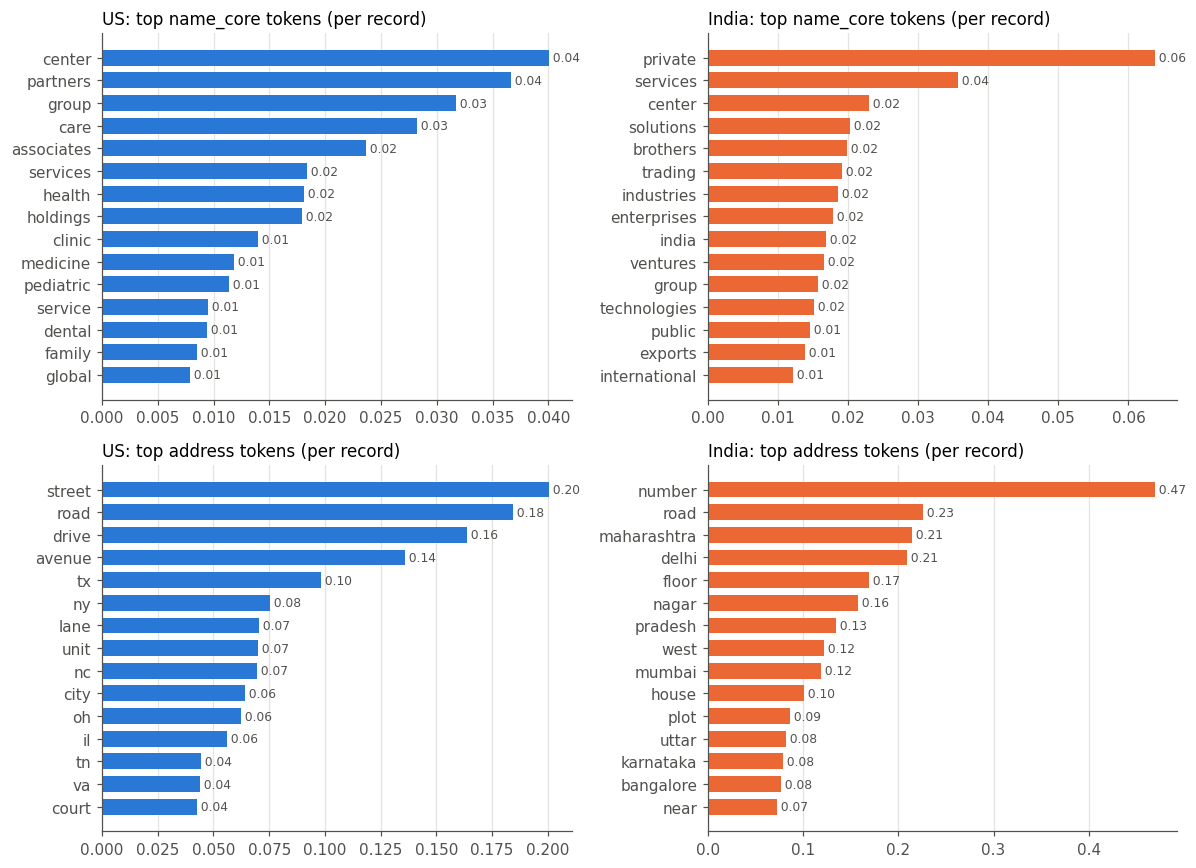

In [23]:
def top_tokens(s: pd.Series, n: int = 20, ngram: int = 1) -> pd.Series:
    c = Counter()
    for toks in s.str.split():
        c.update(" ".join(toks[i:i + ngram]) for i in range(len(toks) - ngram + 1))
    return pd.Series(dict(c.most_common(n)))


cs_train = clean_sample.query("split == 'train'")
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for j, country in enumerate(["US", "India"]):
    g = cs_train.query("country == @country")
    barh(axes[0, j], top_tokens(g.name_core, 15) / len(g), COUNTRY_COLORS[country],
         f"{country}: top name_core tokens (per record)", "{:.2f}")
    barh(axes[1, j], top_tokens(g.addr_norm.str.replace(",", " "), 15) / len(g), COUNTRY_COLORS[country],
         f"{country}: top address tokens (per record)", "{:.2f}")
plt.tight_layout()

In [24]:
print("Top name bigrams by country (train, cleaned):")
display(pd.concat({c: top_tokens(cs_train.query("country == @c").name_core, 12, ngram=2).reset_index()
                   .set_axis(["bigram", "count"], axis=1) for c in ["US", "India"]}, axis=1))

Top name bigrams by country (train, cleaned):


US                       India      
                 bigram count                bigram count
0       care associates  3359                pra li  3680
1             tri state  2416      piraivet limitet  2226
2      physical therapy  2134             new delhi  1720
3      pediatric dental  1920       praivrr limirrd  1252
4   pediatric dentistry  1889  institute technology   844
5              ear nose  1887         public school   834
6     behavioral health  1879        memorial trust   811
7         womens health  1850      charitable trust   792
8           urgent care  1817       welfare society   790
9     internal medicine  1811   educational society   789
10         primary care  1795        medical centre   781
11           foot ankle  1766  international school   767

### 7.2 Legal forms
Legal suffixes are strong *negative* evidence when they conflict (an `llc` vs a `private limited`)
but weak positive evidence (thousands of businesses are `llc`). Their distribution also differs by
source, as some sources drop suffixes, which is why they are split into their own feature.

In [25]:
lf = cs_train.assign(legal_form=cs_train.legal_form.replace("", "(none)"))
lf_tab = pd.crosstab(lf.legal_form, [lf.country, lf.source], normalize="columns")
lf_tab = lf_tab.loc[lf_tab.max(axis=1).sort_values(ascending=False).index[:12]]
lf_tab.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None)

### 7.3 Vocabulary overlap between sources
How much of a source's cleaned vocabulary is shared with S1, raw vs cleaned. Cleaning should raise
overlap substantially (casing, transliteration and abbreviations otherwise split one word into many).

In [26]:
def vocab(s: pd.Series) -> set:
    return set(t for toks in s.str.split() for t in toks)


rows = []
for col_raw, col_clean, label in [("business_name", "name_norm", "name"), ("business_address", "addr_norm", "address")]:
    for country in ["US", "India"]:
        g = cs_train.query("country == @country")
        s1_raw, s1_clean = vocab(g.query("source=='S1'")[col_raw]), vocab(g.query("source=='S1'")[col_clean].str.replace(",", " "))
        for src in ["S2", "S3"]:
            gs = g.query("source == @src")
            v_raw, v_clean = vocab(gs[col_raw]), vocab(gs[col_clean].str.replace(",", " "))
            rows.append({"field": label, "country": country, "source": src,
                         "vocab raw": len(v_raw), "vocab clean": len(v_clean),
                         "% in S1 vocab (raw)": len(v_raw & s1_raw) / len(v_raw),
                         "% in S1 vocab (clean)": len(v_clean & s1_clean) / len(v_clean)})
pd.DataFrame(rows).style.format({"vocab raw": "{:,}", "vocab clean": "{:,}",
                                 "% in S1 vocab (raw)": "{:.1%}", "% in S1 vocab (clean)": "{:.1%}"})

,field,country,source,vocab raw,vocab clean,% in S1 vocab (raw),% in S1 vocab (clean)
0,name,US,S2,"106,325","68,168",23.9%,36.6%
1,name,US,S3,"100,092","69,858",26.9%,35.5%
2,name,India,S2,"57,792","41,706",27.5%,41.1%
3,name,India,S3,"56,253","44,630",30.1%,38.6%
4,address,US,S2,"109,443","85,410",19.3%,43.2%
5,address,US,S3,"106,625","85,900",40.4%,43.6%
6,address,India,S2,"169,703","134,438",8.3%,40.2%
7,address,India,S3,"153,124","121,440",36.6%,41.4%


## 8. Pair-level EDA: does cleaning separate matches from non-matches?

For the sampled ground-truth entities we build:
* **matches**: every (S1, S2/S3) pair from the ground truth
* **random non-matches**: each S1 paired with a random S2/S3 record of the same country
* **hard non-matches**: a non-matching S2/S3 record sharing the S1's first `name_core` token and
  country. This is what a real blocker surfaces, and it is where the F0.5 precision battle is fought.

We compare similarity distributions on **raw** vs **cleaned** fields.

In [27]:
tr_clean = clean.query("split == 'train'").drop_duplicates("entity_id").set_index("entity_id")
s1_ids = gt_sample.source1_entity_id[gt_sample.source1_entity_id.isin(tr_clean.index)].to_numpy()
true_set = set(zip(pairs_gt.source1_entity_id, pairs_gt.match_id))

pool = clean_sample.query("split == 'train' and source != 'S1'")[["entity_id", "country", "name_core"]]
pool_by_country = {c: g.entity_id.to_numpy() for c, g in pool.groupby("country")}
pool["first_tok"] = pool.name_core.str.split().str[0]
pool_by_tok = pool.dropna(subset=["first_tok"]).groupby(["country", "first_tok"]).entity_id.agg(list)

neg_rand, neg_hard = [], []
for s1 in s1_ids:
    c = tr_clean.at[s1, "country"]
    cand = pool_by_country.get(c)
    if cand is not None:
        pick = cand[rng.integers(len(cand))]
        if (s1, pick) not in true_set:
            neg_rand.append((s1, pick))
    toks = tr_clean.at[s1, "name_core"].split()
    if toks:
        hard = [x for x in pool_by_tok.get((c, toks[0]), []) if (s1, x) not in true_set]
        if hard:
            neg_hard.append((s1, hard[rng.integers(len(hard))]))

pairs = pd.concat([
    pairs_gt[pairs_gt.match_id.isin(tr_clean.index)].set_axis(["s1", "other"], axis=1).assign(label="match"),
    pd.DataFrame(neg_rand, columns=["s1", "other"]).assign(label="non-match (random)"),
    pd.DataFrame(neg_hard, columns=["s1", "other"]).assign(label="non-match (hard)"),
], ignore_index=True)
L, R = tr_clean.loc[pairs.s1].reset_index(drop=True), tr_clean.loc[pairs.other].reset_index(drop=True)
pairs["other_source"] = R.source.to_numpy()
pairs["country"] = L.country.to_numpy()
pairs.label.value_counts()

label
match                 69493
non-match (random)    20000
non-match (hard)      18725
Name: count, dtype: int64

In [28]:
def sim(a: pd.Series, b: pd.Series, scorer) -> np.ndarray:
    return np.fromiter((scorer(x, y) for x, y in zip(a, b)), float, len(a)) / 100


def jaccard(a: pd.Series, b: pd.Series) -> np.ndarray:
    def j(x, y):
        x, y = set(x.split()), set(y.split())
        return len(x & y) / len(x | y) if x | y else 0.0
    return np.fromiter((j(x, y) for x, y in zip(a, b)), float, len(a))


feat = pd.DataFrame({
    "name raw (token_sort)": sim(L.business_name, R.business_name, fuzz.token_sort_ratio),
    "name clean (token_sort)": sim(L.name_norm, R.name_norm, fuzz.token_sort_ratio),
    "name_core (token_set)": sim(L.name_core, R.name_core, fuzz.token_set_ratio),
    "name_core (jaccard)": jaccard(L.name_core, R.name_core),
    "addr raw (token_sort)": sim(L.business_address, R.business_address, fuzz.token_sort_ratio),
    "addr clean (token_set)": sim(L.addr_tokens_sorted, R.addr_tokens_sorted, fuzz.token_set_ratio),
    "postcode equal": ((L.postcode == R.postcode) & L.postcode.ne("")).astype(float).to_numpy(),
    "region equal": ((L.region == R.region) & L.region.ne("")).astype(float).to_numpy(),
    "legal_form conflict": ((L.legal_form != R.legal_form) & L.legal_form.ne("") & R.legal_form.ne("")).astype(float).to_numpy(),
})


def auc(pos: np.ndarray, neg: np.ndarray) -> float:
    """ROC AUC via the Mann-Whitney rank statistic."""
    ranks = pd.Series(np.r_[pos, neg]).rank().to_numpy()
    return (ranks[: len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))


is_m = pairs.label.eq("match").to_numpy()
auc_tab = pd.DataFrame({
    neg: {f: auc(feat.loc[is_m, f].to_numpy(), feat.loc[pairs.label.eq(neg).to_numpy(), f].to_numpy()) for f in feat}
    for neg in ["non-match (random)", "non-match (hard)"]})
auc_tab.insert(0, "mean | match", feat[is_m].mean())
auc_tab.insert(1, "mean | hard non-match", feat[pairs.label.eq("non-match (hard)").to_numpy()].mean())
auc_tab.style.format("{:.3f}").background_gradient(cmap="Blues", subset=["non-match (random)", "non-match (hard)"])

,mean | match,mean | hard non-match,non-match (random),non-match (hard)
name raw (token_sort),0.695,0.447,0.851,0.764
name clean (token_sort),0.852,0.535,0.969,0.908
name_core (token_set),0.914,0.640,0.982,0.865
name_core (jaccard),0.698,0.294,0.933,0.815
addr raw (token_sort),0.596,0.278,0.920,0.914
addr clean (token_set),0.926,0.373,0.957,0.955
postcode equal,0.050,0.000,0.525,0.525
region equal,0.947,0.102,0.938,0.923
legal_form conflict,0.037,0.259,0.394,0.389


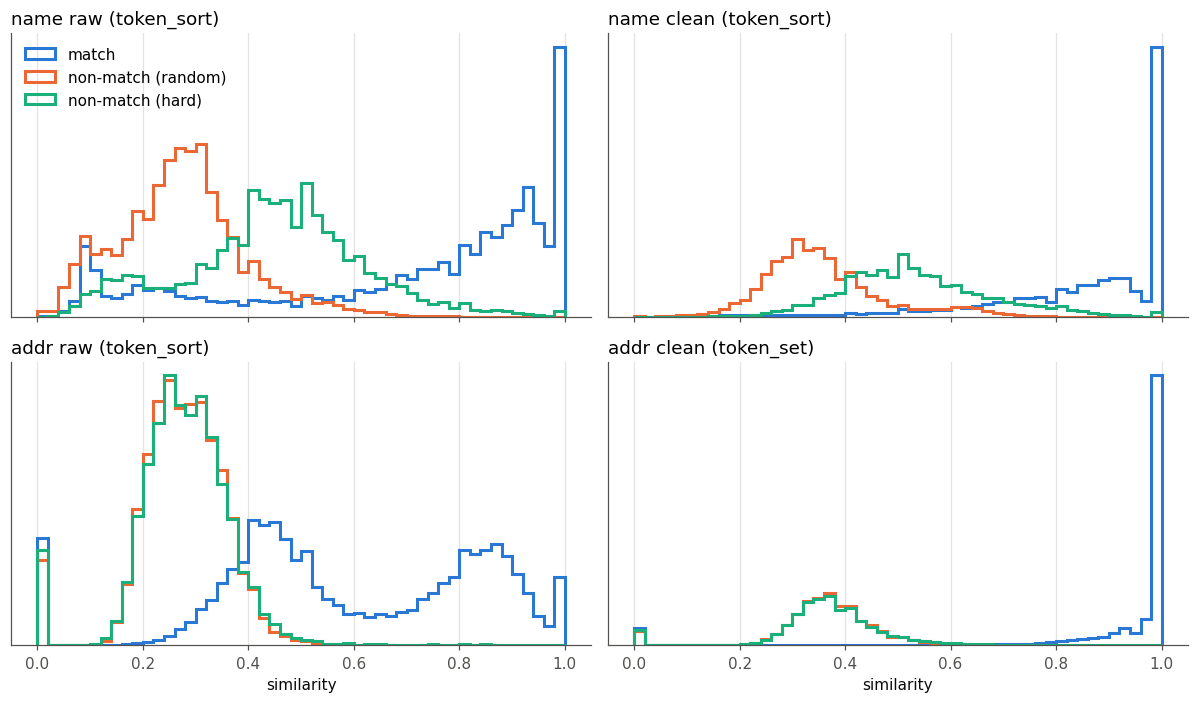

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, f in zip(axes.flat, ["name raw (token_sort)", "name clean (token_sort)", "addr raw (token_sort)", "addr clean (token_set)"]):
    for lab, color in MATCH_COLORS.items():
        ax.hist(feat.loc[pairs.label.eq(lab).to_numpy(), f], bins=50, range=(0, 1), density=True,
                histtype="step", linewidth=2, color=color, label=lab)
    ax.set_title(f, loc="left")
    ax.set_yticks([])
axes[0, 0].legend(loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("similarity")
plt.tight_layout()

### 8.1 Similarity of true matches by source and country
Which source/country combinations are hardest? Low-similarity true matches are where recall will be
lost; this breakdown tells us where extra cleaning or dedicated features pay off.

In [30]:
m = pairs[is_m].assign(**feat[is_m].reset_index(drop=True).set_index(pairs.index[is_m]))
m.groupby(["country", "other_source"])[["name clean (token_sort)", "name_core (token_set)",
                                        "addr clean (token_set)", "postcode equal", "region equal"]].mean() \
    .style.format("{:.2f}").background_gradient(cmap="Blues", axis=0)

In [31]:
# The hardest true matches after cleaning: inspect what cleaning still misses
worst = m.nsmallest(12, "name_core (token_set)").index
pd.DataFrame({
    "S1 name": L.loc[worst, "business_name"].to_numpy(), "other name": R.loc[worst, "business_name"].to_numpy(),
    "S1 core": L.loc[worst, "name_core"].to_numpy(), "other core": R.loc[worst, "name_core"].to_numpy(),
    "src": pairs.loc[worst, "other_source"].to_numpy(),
})

,S1 name,other name,S1 core,other core,src
0,Singhal & Co,S.Com,singhal,,S3
1,Seattle Terra,Novinovi,seattle terra,novinovi,S3
2,Q 2 H Sachem LLC,5ynbrix,q 2 h sachem,5ynbrix,S2
3,Patidar Clinic,PC,patidar clinic,,S3
4,Mallick & Sons Private Limited,MS,mallick sons,,S3
5,Laxmi Projects,LP,laxmi projects,,S3
6,Shivam Aircon LLP,SA,shivam aircon,,S3
7,Sai & Co,s.com #21437,sai,,S2
8,Shree & Co,Shree & Co.,,,S3
9,Rvk & Co,Deltaquo,rvk,deltaquo,S3


### 8.2 Blocking-key coverage
A blocking key is useful if **true matches almost always share it** (recall ceiling) while
**few random pairs do** (reduction ratio). Estimated on the sampled pairs.

In [32]:
def share(key_l: pd.Series, key_r: pd.Series) -> np.ndarray:
    return ((key_l.to_numpy() == key_r.to_numpy()) & (key_l.to_numpy() != "")).astype(float)


def first_tok(s): return s.str.split().str[0].fillna("")
def sorted_first_tok(s): return s.str.split().map(lambda t: min(t, default=""))
def core_prefix(s, n=4): return s.str.replace(" ", "", regex=False).str[:n]


keys = pd.DataFrame({
    "country": share(L.country, R.country),
    "postcode": share(L.postcode, R.postcode),
    "region": share(L.region, R.region),
    "name_core first token": share(first_tok(L.name_core), first_tok(R.name_core)),
    "name_core alphabetically-first token": share(sorted_first_tok(L.name_core), sorted_first_tok(R.name_core)),
    "any shared name_core token": (jaccard(L.name_core, R.name_core) > 0).astype(float),
    "postcode OR shared name token": np.maximum(share(L.postcode, R.postcode), (jaccard(L.name_core, R.name_core) > 0)),
    "house_no": share(L.house_no, R.house_no),
})
keys.groupby(pairs.label.to_numpy()).mean().T.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None)

,match,non-match (hard),non-match (random)
country,100.0%,100.0%,100.0%
postcode,5.0%,0.0%,0.0%
region,94.7%,10.2%,7.0%
name_core first token,79.2%,100.0%,0.1%
name_core alphabetically-first token,71.8%,27.6%,0.2%
any shared name_core token,86.7%,100.0%,0.9%
postcode OR shared name token,87.2%,100.0%,0.9%
house_no,36.4%,0.0%,0.0%


## 9. Train vs test drift
The test set introduces **France**. Compare field statistics and look at what the pipeline does to
French records, since nothing was tuned on French training data.

In [33]:
cs = clean_sample.assign(name_tokens=clean_sample.name_norm.str.split().str.len(),
                         addr_tokens=clean_sample.addr_norm.str.split().str.len())
drift = cs.groupby(["split", "country"]).agg(
    rows=("entity_id", "size"), name_tokens=("name_tokens", "median"), addr_tokens=("addr_tokens", "median"),
    has_legal_form=("legal_form", lambda s: s.ne("").mean()), has_postcode=("postcode", lambda s: s.ne("").mean()),
    has_region=("region", lambda s: s.ne("").mean()))
drift.style.format({"rows": "{:,}", "has_legal_form": "{:.1%}", "has_postcode": "{:.1%}", "has_region": "{:.1%}"})

,source,business_name,name_norm,legal_form,business_address,addr_norm,region,postcode
1137167,S1,Communaute Amicale SAS,communaute amicale sas,sas,"13 Avenue Bel Air, Bordeaux, Nouvelle-Aquitaine","13 avenue bel air, bordeaux, nouvelle-aquitaine",nouvelle-aquitaine,
1247926,S1,Family Promo Club SAS,family promo club sas,sas,"34 Route de la Villes-Bousseau, Saint-Nazaire, Pays de la Loire","34 route de la villes-bousseau, saint-nazaire, pays de la loire",pays de la loire,
1064050,S1,Saint-Nazaire Centre,saint nazaire centre,,"11 Rue César Franck, Saint-Nazaire, Pays de la Loire","11 rue cesar franck, saint-nazaire, pays de la loire",pays de la loire,
1022944,S1,Établissements Metropole SAS,etablissements metropole sas,sas,"12 Rue du Brésil, Tourcoing, Hauts-de-France","12 rue du bresil, tourcoing, hauts-de-france",hauts-de-france,
1351735,S2,Pessac Ecole (SARL),pessac ecole sarl,sarl,"# 2 AVENUE DE LA SOURCE, PESSAC, Gironde","2 avenue de la source, pessac, gironde",,
1424915,S2,GUYOT FETES SCI,guyot fetes sci,sci,"50 R. SAINT-RÉMI, BORDEAUX","50 rue saint-remi, bordeaux",,
1525293,S2,Club du Tous,club du tous,,"AV. DU DOCTEUR NANCEL PÉNARD, PESSAC, Nouvelle-Aquitaine","avenue du docteur nancel penard, pessac, nouvelle-aquitaine",nouvelle-aquitaine,
1427976,S2,Ass & Fîls SARL,ass and fils sarl,sarl,"14 RUE DE BERGUES, LILLE","14 rue de bergues, lille",,
1799292,S3,Nantes Comite SAS,nantes comite sas,sas,"45 Rue De La Maison Blanche, Nantes, Loire-Atlantique","45 rue de la maison blanche, nantes, loire-atlantique",,
1794781,S3,Aide Comite Participations SAS,aide comite participations sas,sas,"25 R. Buchu, Bordeaux, Gironde","25 rue buchu, bordeaux, gironde",,


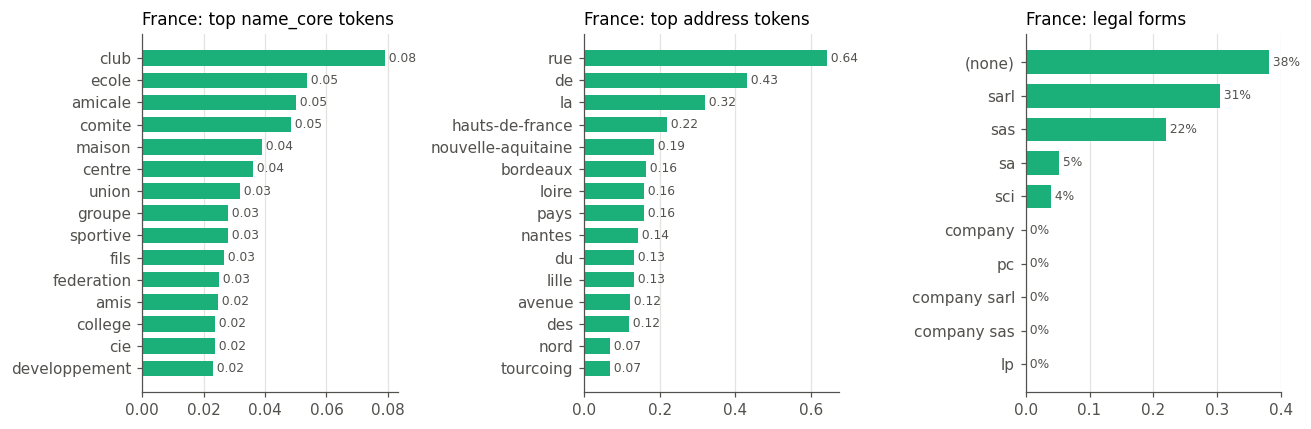

In [34]:
fr = cs.query("country == 'France'")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
barh(axes[0], top_tokens(fr.name_core, 15) / len(fr), COUNTRY_COLORS["France"], "France: top name_core tokens", "{:.2f}")
barh(axes[1], top_tokens(fr.addr_norm.str.replace(",", " "), 15) / len(fr), COUNTRY_COLORS["France"],
     "France: top address tokens", "{:.2f}")
barh(axes[2], fr.legal_form.replace("", "(none)").value_counts().head(10) / len(fr), COUNTRY_COLORS["France"],
     "France: legal forms", "{:.0%}")
plt.tight_layout()

fr.groupby("source").sample(4, random_state=0)[["source", "business_name", "name_norm", "legal_form",
                                                 "business_address", "addr_norm", "region", "postcode"]]

## 10. Full-data cleaning export
Streams every file chunk by chunk through `clean_records` and writes one parquet file per source,
keeping raw and cleaned columns. Flip `RUN_FULL_CLEAN = True` at the top to run it (it takes a while).

In [35]:
def clean_file(path: Path, out: Path) -> None:
    import pyarrow as pa
    import pyarrow.parquet as pq
    writer = None
    for chunk in pd.read_csv(path, chunksize=CHUNK, **READ_KW):
        table = pa.Table.from_pandas(clean_records(chunk), preserve_index=False)
        writer = writer or pq.ParquetWriter(out, table.schema, compression="zstd")
        writer.write_table(table)
    if writer:
        writer.close()


if RUN_FULL_CLEAN:
    OUT_DIR.mkdir(exist_ok=True)
    for (split, src), path in FILES.items():
        t0 = time.time()
        clean_file(path, OUT_DIR / f"{split}_{src.lower()}_clean.parquet")
        print(f"{split}/{src} done in {time.time() - t0:.0f}s")
else:
    print("RUN_FULL_CLEAN is False: skipping full export")

RUN_FULL_CLEAN is False: skipping full export


## 11. Key findings
_Fill in after running on the full data: headline numbers from sections 3–9 (singleton rate,
noise rates per source, raw-vs-clean AUCs, blocking-key recall) and the cleaning gaps from 8.1._